In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Deep Learning (LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load datasets from Colab environment

ftse = pd.read_csv('/content/FTSE 100 Historical Results Price Data (2).csv')
rates = pd.read_excel('/content/Bank Rate history and data  Bank of England Database.xlsx')

# Preview datasets
print("FTSE Data Sample:")
display(ftse.head())

print("\nBank Rate Data Sample:")
display(rates.head())

FTSE Data Sample:


,Date,Price,Open,High,Low,Vol.,Change %
0,31/12/2025,"9,931.38","9,940.70","9,950.11","9,916.70",176.05M,-0.09%
1,30/12/2025,"9,940.71","9,866.53","9,954.32","9,859.77",364.74M,0.75%
2,29/12/2025,"9,866.53","9,870.69","9,892.79","9,858.46",341.17M,-0.04%
3,24/12/2025,"9,870.68","9,889.20","9,893.15","9,862.04",163.41M,-0.19%
4,23/12/2025,"9,889.22","9,865.94","9,901.48","9,846.29",534.19M,0.24%



Bank Rate Data Sample:


,Date Changed,Rate
0,18 Dec 25,3.7500
1,07 Aug 25,4.0000
2,08 May 25,4.2500
3,06 Feb 25,4.5000
4,07 Nov 24,4.7500


In [ ]:
# Convert date column to datetime format and sort data

ftse['Date'] = pd.to_datetime(ftse['Date'], dayfirst=True)

# Remove commas and convert price columns to float
ftse['Price'] = ftse['Price'].str.replace(',', '').astype(float)
ftse['Open'] = ftse['Open'].str.replace(',', '').astype(float)
ftse['High'] = ftse['High'].str.replace(',', '').astype(float)
ftse['Low'] = ftse['Low'].str.replace(',', '').astype(float)

# Sort dataset by date
ftse = ftse.sort_values('Date')

# Check cleaned data
display(ftse.head())

,Date,Price,Open,High,Low,Vol.,Change %
2776,2015-01-06,6366.5100,6417.1600,6452.6600,6328.5900,793.26M,-0.79%
2775,2015-01-07,6419.8300,6366.5100,6459.7400,6366.5100,709.50M,0.84%
2774,2015-01-08,6569.9600,6419.8300,6580.8200,6419.8300,910.04M,2.34%
2773,2015-01-09,6501.1400,6569.9600,6570.2400,6471.3800,761.33M,-1.05%
2772,2015-01-12,6501.4200,6501.1400,6542.4300,6447.9100,620.94M,0.00%


In [ ]:
# Convert Volume column (M = million, B = billion)

def convert_volume(v):
    if isinstance(v, str):
        if 'M' in v:
            return float(v.replace('M', '')) * 1e6
        elif 'B' in v:
            return float(v.replace('B', '')) * 1e9
    return float(v)

ftse['Volume'] = ftse['Vol.'].apply(convert_volume)

# Convert percentage change to numeric
ftse['Change'] = ftse['Change %'].str.replace('%', '').astype(float) / 100

# Drop original columns if not needed
ftse = ftse.drop(columns=['Vol.', 'Change %'])

display(ftse.head())

,Date,Price,Open,High,Low,Volume,Change
2776,2015-01-06,6366.5100,6417.1600,6452.6600,6328.5900,793260000.0000,-0.0079
2775,2015-01-07,6419.8300,6366.5100,6459.7400,6366.5100,709500000.0000,0.0084
2774,2015-01-08,6569.9600,6419.8300,6580.8200,6419.8300,910040000.0000,0.0234
2773,2015-01-09,6501.1400,6569.9600,6570.2400,6471.3800,761330000.0000,-0.0105
2772,2015-01-12,6501.4200,6501.1400,6542.4300,6447.9100,620940000.0000,0.0000


In [ ]:
# Convert 'Date Changed' to datetime

rates['Date'] = pd.to_datetime(rates['Date Changed'], dayfirst=True)

# Keep only relevant columns
rates = rates[['Date', 'Rate']]

# Sort by date
rates = rates.sort_values('Date')

display(rates.head())

,Date,Rate
244,1976-01-05,11.0000
243,1976-01-19,10.7500
242,1976-01-26,10.5000
241,1976-02-02,10.0000
240,1976-02-09,9.5000


In [ ]:
# Merge datasets using left join (keep all FTSE dates)

df = pd.merge(ftse, rates, on='Date', how='left')

# Check merged data
display(df.head(10))

,Date,Price,Open,High,Low,Volume,Change,Rate
0,2015-01-06,6366.5100,6417.1600,6452.6600,6328.5900,793260000.0000,-0.0079,NaN
1,2015-01-07,6419.8300,6366.5100,6459.7400,6366.5100,709500000.0000,0.0084,NaN
2,2015-01-08,6569.9600,6419.8300,6580.8200,6419.8300,910040000.0000,0.0234,NaN
3,2015-01-09,6501.1400,6569.9600,6570.2400,6471.3800,761330000.0000,-0.0105,NaN
4,2015-01-12,6501.4200,6501.1400,6542.4300,6447.9100,620940000.0000,0.0000,NaN
5,2015-01-13,6542.2000,6501.4200,6558.8300,6465.1900,694410000.0000,0.0063,NaN
6,2015-01-14,6388.4600,6542.2000,6542.2000,6353.6500,1000000000.0000,-0.0235,NaN
7,2015-01-15,6498.7800,6388.4600,6498.7800,6298.1500,1010000000.0000,0.0173,NaN
8,2015-01-16,6550.2700,6498.7800,6553.2000,6443.2800,830660000.0000,0.0079,NaN
9,2015-01-19,6585.5300,6550.2700,6598.8900,6548.0000,554550000.0000,0.0054,NaN


In [ ]:
# Fill missing interest rates (since rates do not change daily)

# Forward fill (propagate future known rates forward)
df['Rate'] = df['Rate'].ffill()

# Backward fill (fill initial missing values using earliest available rate)
df['Rate'] = df['Rate'].bfill()

# Check results
display(df[['Date', 'Rate']].head(10))

,Date,Rate
0,2015-01-06,0.2500
1,2015-01-07,0.2500
2,2015-01-08,0.2500
3,2015-01-09,0.2500
4,2015-01-12,0.2500
5,2015-01-13,0.2500
6,2015-01-14,0.2500
7,2015-01-15,0.2500
8,2015-01-16,0.2500
9,2015-01-19,0.2500


In [ ]:
# Calculate rate change
df['Rate_Change'] = df['Rate'].diff()

# Binary indicator: 1 if rate changed, else 0
df['Rate_Event'] = (df['Rate_Change'] != 0).astype(int)

# Direction of change: +1 (increase), -1 (decrease), 0 (no change)
df['Rate_Direction'] = df['Rate_Change'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

display(df[['Date', 'Rate', 'Rate_Change', 'Rate_Event', 'Rate_Direction']].head(10))

,Date,Rate,Rate_Change,Rate_Event,Rate_Direction
0,2015-01-06,0.2500,NaN,1,0
1,2015-01-07,0.2500,0.0000,0,0
2,2015-01-08,0.2500,0.0000,0,0
3,2015-01-09,0.2500,0.0000,0,0
4,2015-01-12,0.2500,0.0000,0,0
5,2015-01-13,0.2500,0.0000,0,0
6,2015-01-14,0.2500,0.0000,0,0
7,2015-01-15,0.2500,0.0000,0,0
8,2015-01-16,0.2500,0.0000,0,0
9,2015-01-19,0.2500,0.0000,0,0


In [ ]:
# Calculate daily returns

df['Return'] = df['Price'].pct_change()

display(df[['Date', 'Price', 'Return']].head(10))

,Date,Price,Return
0,2015-01-06,6366.5100,NaN
1,2015-01-07,6419.8300,0.0084
2,2015-01-08,6569.9600,0.0234
3,2015-01-09,6501.1400,-0.0105
4,2015-01-12,6501.4200,0.0000
5,2015-01-13,6542.2000,0.0063
6,2015-01-14,6388.4600,-0.0235
7,2015-01-15,6498.7800,0.0173
8,2015-01-16,6550.2700,0.0079
9,2015-01-19,6585.5300,0.0054


In [ ]:
# Create lagged returns (previous days)

df['Lag1'] = df['Return'].shift(1)
df['Lag2'] = df['Return'].shift(2)
df['Lag3'] = df['Return'].shift(3)

display(df[['Date', 'Return', 'Lag1', 'Lag2', 'Lag3']].head(10))

,Date,Return,Lag1,Lag2,Lag3
0,2015-01-06,NaN,NaN,NaN,NaN
1,2015-01-07,0.0084,NaN,NaN,NaN
2,2015-01-08,0.0234,0.0084,NaN,NaN
3,2015-01-09,-0.0105,0.0234,0.0084,NaN
4,2015-01-12,0.0000,-0.0105,0.0234,0.0084
5,2015-01-13,0.0063,0.0000,-0.0105,0.0234
6,2015-01-14,-0.0235,0.0063,0.0000,-0.0105
7,2015-01-15,0.0173,-0.0235,0.0063,0.0000
8,2015-01-16,0.0079,0.0173,-0.0235,0.0063
9,2015-01-19,0.0054,0.0079,0.0173,-0.0235


In [ ]:
# Rolling mean and volatility (5-day window)

df['Rolling_Mean_5'] = df['Return'].rolling(5).mean()
df['Rolling_Std_5'] = df['Return'].rolling(5).std()

# High-Low spread (intraday volatility proxy)
df['High_Low_Spread'] = df['High'] - df['Low']

# Momentum (5-day)
df['Momentum'] = df['Price'] - df['Price'].shift(5)

display(df.head(10))

,Date,Price,Open,High,Low,Volume,Change,Rate,Rate_Change,Rate_Event,Rate_Direction,Return,Lag1,Lag2,Lag3,Rolling_Mean_5,Rolling_Std_5,High_Low_Spread,Momentum
0,2015-01-06,6366.5100,6417.1600,6452.6600,6328.5900,793260000.0000,-0.0079,0.2500,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,124.0700,NaN
1,2015-01-07,6419.8300,6366.5100,6459.7400,6366.5100,709500000.0000,0.0084,0.2500,0.0000,0,0,0.0084,NaN,NaN,NaN,NaN,NaN,93.2300,NaN
2,2015-01-08,6569.9600,6419.8300,6580.8200,6419.8300,910040000.0000,0.0234,0.2500,0.0000,0,0,0.0234,0.0084,NaN,NaN,NaN,NaN,160.9900,NaN
3,2015-01-09,6501.1400,6569.9600,6570.2400,6471.3800,761330000.0000,-0.0105,0.2500,0.0000,0,0,-0.0105,0.0234,0.0084,NaN,NaN,NaN,98.8600,NaN
4,2015-01-12,6501.4200,6501.1400,6542.4300,6447.9100,620940000.0000,0.0000,0.2500,0.0000,0,0,0.0000,-0.0105,0.0234,0.0084,NaN,NaN,94.5200,NaN
5,2015-01-13,6542.2000,6501.4200,6558.8300,6465.1900,694410000.0000,0.0063,0.2500,0.0000,0,0,0.0063,0.0000,-0.0105,0.0234,0.0055,0.0124,93.6400,175.6900
6,2015-01-14,6388.4600,6542.2000,6542.2000,6353.6500,1000000000.0000,-0.0235,0.2500,0.0000,0,0,-0.0235,0.0063,0.0000,-0.0105,-0.0009,0.0176,188.5500,-31.3700
7,2015-01-15,6498.7800,6388.4600,6498.7800,6298.1500,1010000000.0000,0.0173,0.2500,0.0000,0,0,0.0173,-0.0235,0.0063,0.0000,-0.0021,0.0156,200.6300,-71.1800
8,2015-01-16,6550.2700,6498.7800,6553.2000,6443.2800,830660000.0000,0.0079,0.2500,0.0000,0,0,0.0079,0.0173,-0.0235,0.0063,0.0016,0.0153,109.9200,49.1300
9,2015-01-19,6585.5300,6550.2700,6598.8900,6548.0000,554550000.0000,0.0054,0.2500,0.0000,0,0,0.0054,0.0079,0.0173,-0.0235,0.0027,0.0154,50.8900,84.1100


In [ ]:
# Remove rows with NaN values created by lagging/rolling

df = df.dropna()

# Final dataset preview
display(df.head())
print("Final dataset shape:", df.shape)

,Date,Price,Open,High,Low,Volume,Change,Rate,Rate_Change,Rate_Event,Rate_Direction,Return,Lag1,Lag2,Lag3,Rolling_Mean_5,Rolling_Std_5,High_Low_Spread,Momentum
5,2015-01-13,6542.2000,6501.4200,6558.8300,6465.1900,694410000.0000,0.0063,0.2500,0.0000,0,0,0.0063,0.0000,-0.0105,0.0234,0.0055,0.0124,93.6400,175.6900
6,2015-01-14,6388.4600,6542.2000,6542.2000,6353.6500,1000000000.0000,-0.0235,0.2500,0.0000,0,0,-0.0235,0.0063,0.0000,-0.0105,-0.0009,0.0176,188.5500,-31.3700
7,2015-01-15,6498.7800,6388.4600,6498.7800,6298.1500,1010000000.0000,0.0173,0.2500,0.0000,0,0,0.0173,-0.0235,0.0063,0.0000,-0.0021,0.0156,200.6300,-71.1800
8,2015-01-16,6550.2700,6498.7800,6553.2000,6443.2800,830660000.0000,0.0079,0.2500,0.0000,0,0,0.0079,0.0173,-0.0235,0.0063,0.0016,0.0153,109.9200,49.1300
9,2015-01-19,6585.5300,6550.2700,6598.8900,6548.0000,554550000.0000,0.0054,0.2500,0.0000,0,0,0.0054,0.0079,0.0173,-0.0235,0.0027,0.0154,50.8900,84.1100


Final dataset shape: (2772, 19)


In [ ]:
# Display dataset structure and summary

print("Dataset Shape:", df.shape)

# Data types and non-null counts
print("\nData Info:")
df.info()

# Statistical summary
print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (2772, 19)

Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 2772 entries, 5 to 2776
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2772 non-null   datetime64[ns]
 1   Price            2772 non-null   float64       
 2   Open             2772 non-null   float64       
 3   High             2772 non-null   float64       
 4   Low              2772 non-null   float64       
 5   Volume           2772 non-null   float64       
 6   Change           2772 non-null   float64       
 7   Rate             2772 non-null   float64       
 8   Rate_Change      2772 non-null   float64       
 9   Rate_Event       2772 non-null   int64         
 10  Rate_Direction   2772 non-null   int64         
 11  Return           2772 non-null   float64       
 12  Lag1             2772 non-null   float64       
 13  Lag2             2772 non-null   float64       
 14  Lag3   

,Date,Price,Open,High,Low,Volume,Change,Rate,Rate_Change,Rate_Event,Rate_Direction,Return,Lag1,Lag2,Lag3,Rolling_Mean_5,Rolling_Std_5,High_Low_Spread,Momentum
count,2772,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000
mean,2020-07-05 23:16:52.987013120,7311.3279,7310.1073,7351.7215,7269.5039,818454188.3117,0.0002,1.6380,0.0013,0.0087,0.0029,0.0002,0.0002,0.0002,0.0002,0.0002,0.0079,82.2176,6.1831
min,2015-01-13 00:00:00,4993.8900,4993.8900,5181.0400,4898.7900,112220000.0000,-0.1087,0.1000,-0.5000,0.0000,-1.0000,-0.1087,-0.1087,-0.1087,-0.1087,-0.0474,0.0010,0.0000,-1467.9500
25%,2017-10-08 06:00:00,6867.9875,6866.2975,6910.5250,6827.8975,661170000.0000,-0.0042,0.2500,0.0000,0.0000,0.0000,-0.0042,-0.0042,-0.0042,-0.0042,-0.0017,0.0044,52.1550,-62.3100
50%,2020-07-06 12:00:00,7317.3600,7316.1500,7350.9000,7279.4850,772525000.0000,0.0006,0.5000,0.0000,0.0000,0.0000,0.0006,0.0006,0.0006,0.0006,0.0005,0.0064,69.8250,16.3550
75%,2023-04-03 06:00:00,7623.6900,7623.0575,7657.1875,7585.5650,908575000.0000,0.0050,4.0000,0.0000,0.0000,0.0000,0.0050,0.0050,0.0050,0.0050,0.0024,0.0093,96.6550,87.3800
max,2025-12-31 00:00:00,9940.7100,9940.7000,9954.3200,9916.7000,3880000000.0000,0.0905,5.2500,0.7500,1.0000,1.0000,0.0905,0.0905,0.0905,0.0905,0.0254,0.0591,639.0400,664.1200
std,NaN,805.5410,804.1430,798.5482,811.9337,275209530.6403,0.0097,1.9436,0.0331,0.0927,0.0930,0.0097,0.0097,0.0097,0.0097,0.0043,0.0057,50.4442,146.7494


In [ ]:
# Check for missing values in each column

missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values)

Missing Values:


,0
Date,0
Price,0
Open,0
High,0
Low,0
Volume,0
Change,0
Rate,0
Rate_Change,0
Rate_Event,0


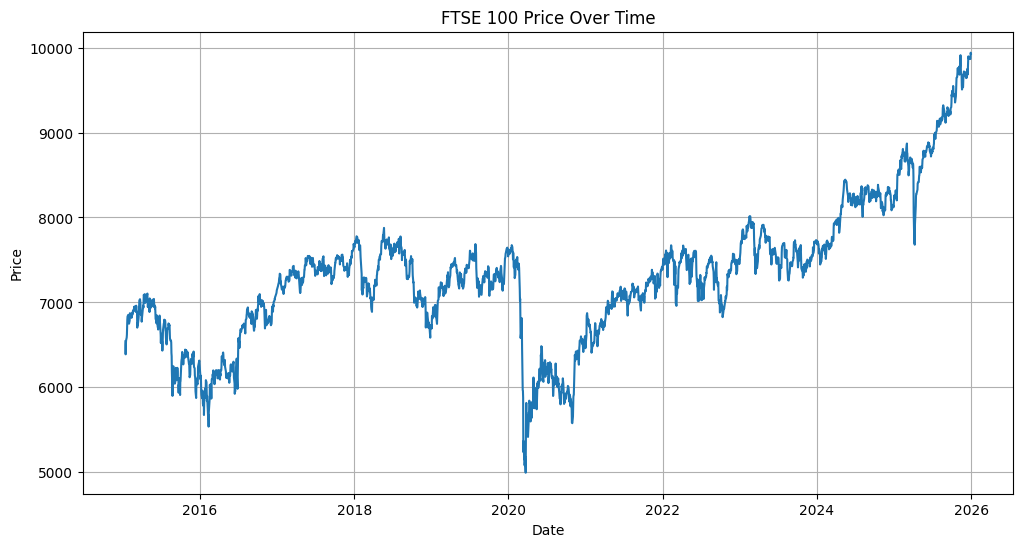

In [ ]:
# Plot FTSE price over time

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'])
plt.title("FTSE 100 Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

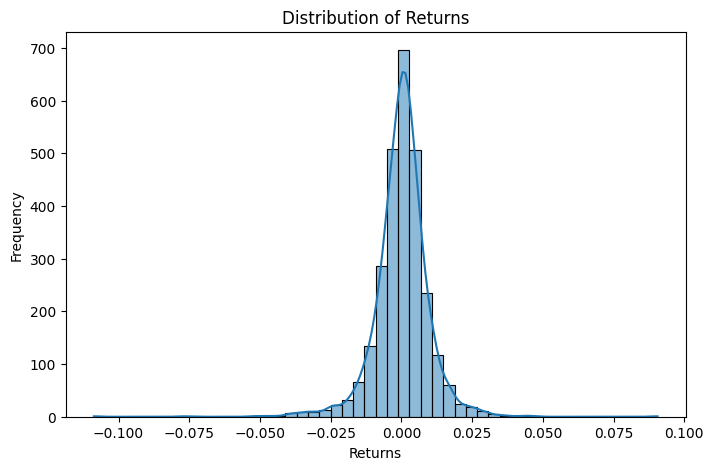

In [ ]:
# Histogram of returns

plt.figure(figsize=(8,5))
sns.histplot(df['Return'], bins=50, kde=True)

plt.title("Distribution of Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()

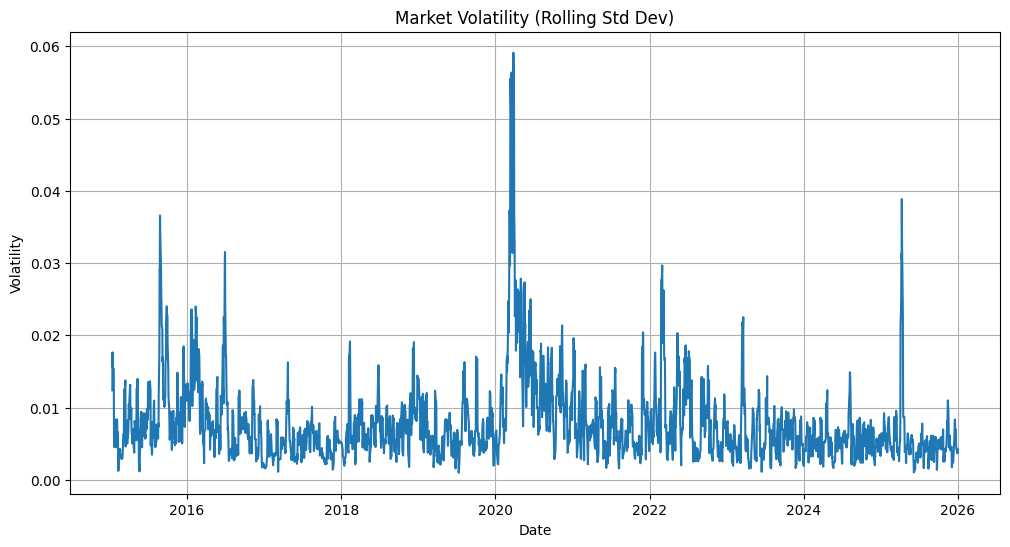

In [ ]:
# Plot rolling standard deviation (volatility)

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Rolling_Std_5'])

plt.title("Market Volatility (Rolling Std Dev)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

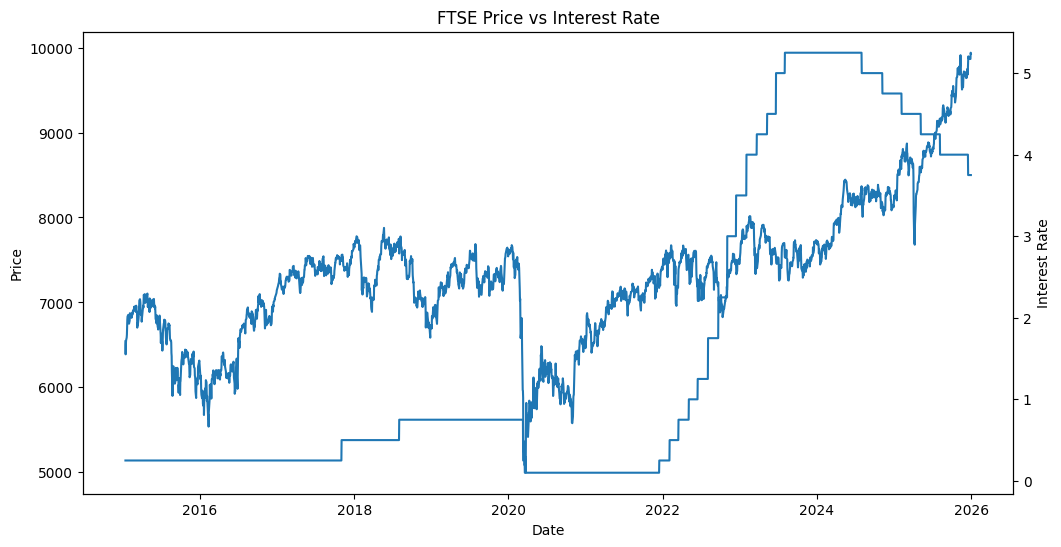

In [ ]:
# Plot interest rate alongside price

fig, ax1 = plt.subplots(figsize=(12,6))

# Price
ax1.plot(df['Date'], df['Price'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Rate (secondary axis)
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Rate'])
ax2.set_ylabel('Interest Rate')

plt.title("FTSE Price vs Interest Rate")
plt.show()

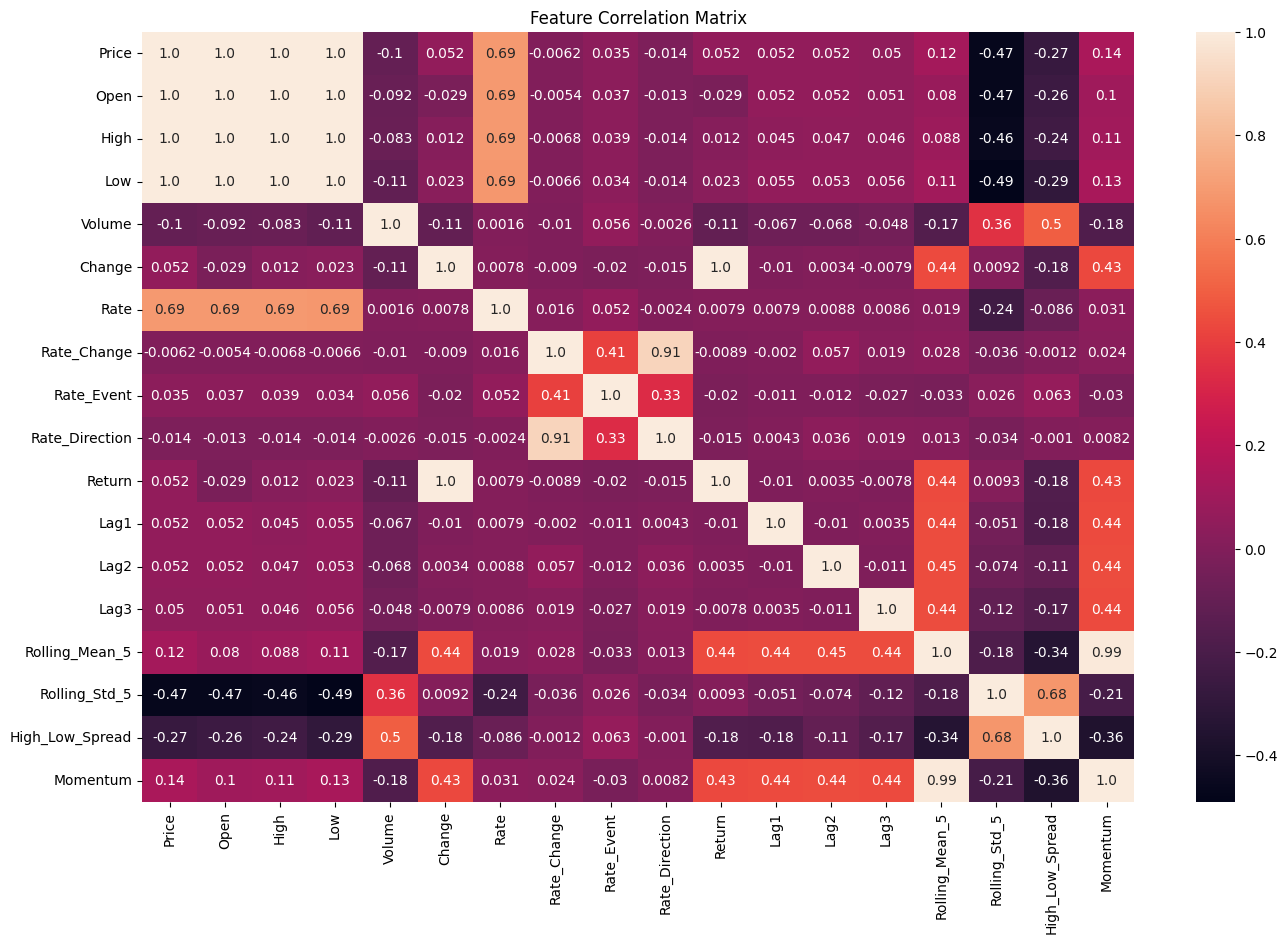

In [ ]:
# Correlation heatmap

plt.figure(figsize=(16,10))

corr = df.drop(columns=['Date']).corr()

sns.heatmap(corr, annot=True, fmt='.2')

plt.title("Feature Correlation Matrix")
plt.show()

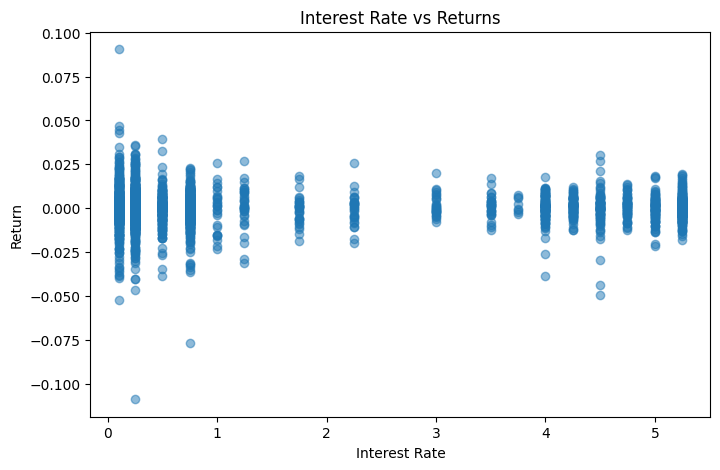

In [ ]:
# Scatter plot: Rate vs Return

plt.figure(figsize=(8,5))
plt.scatter(df['Rate'], df['Return'], alpha=0.5)

plt.title("Interest Rate vs Returns")
plt.xlabel("Interest Rate")
plt.ylabel("Return")
plt.show()

In [ ]:
# Compare returns on rate change days vs normal days

event_returns = df[df['Rate_Event'] == 1]['Return']
normal_returns = df[df['Rate_Event'] == 0]['Return']

print("Mean Return on Rate Change Days:", event_returns.mean())
print("Mean Return on Normal Days:", normal_returns.mean())

Mean Return on Rate Change Days: -0.0019155205737204455
Mean Return on Normal Days: 0.00021846121403600093


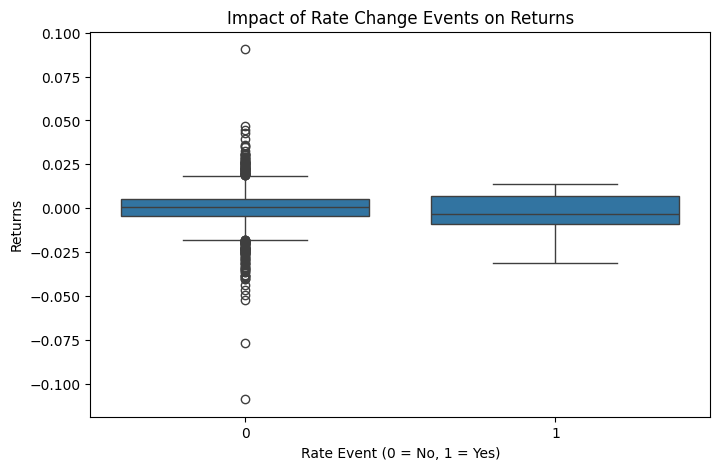

In [ ]:
# Visual comparison of event vs non-event days

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Rate_Event'], y=df['Return'])

plt.title("Impact of Rate Change Events on Returns")
plt.xlabel("Rate Event (0 = No, 1 = Yes)")
plt.ylabel("Returns")
plt.show()

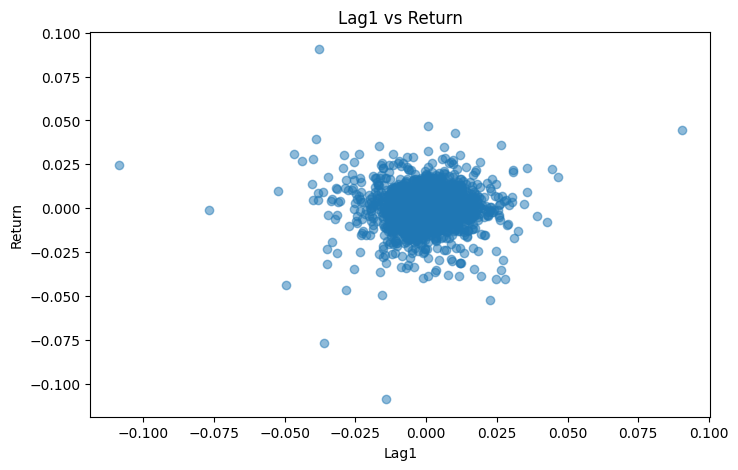

In [ ]:
# Check relationship between lagged returns and current return

plt.figure(figsize=(8,5))
plt.scatter(df['Lag1'], df['Return'], alpha=0.5)

plt.title("Lag1 vs Return")
plt.xlabel("Lag1")
plt.ylabel("Return")
plt.show()

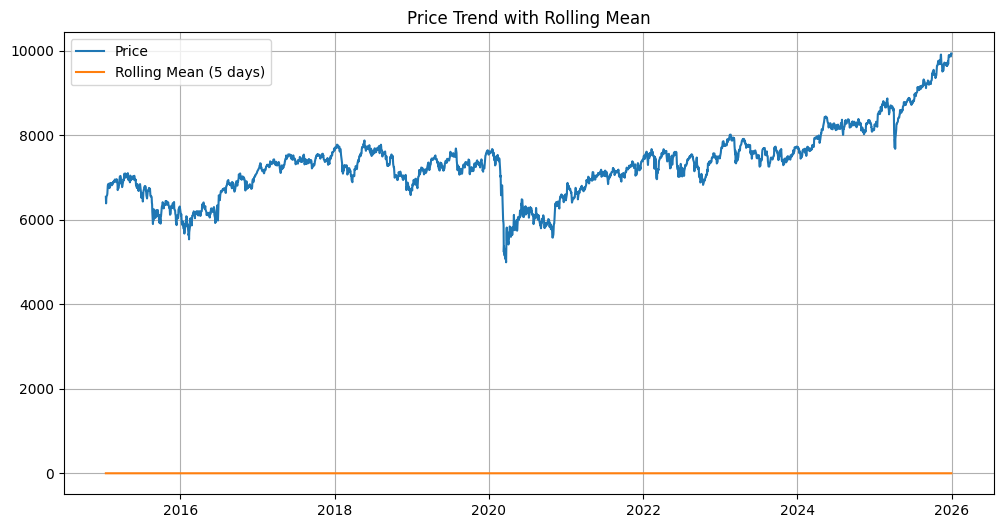

In [ ]:
# Plot price with rolling mean

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Price'], label='Price')
plt.plot(df['Date'], df['Rolling_Mean_5'], label='Rolling Mean (5 days)')

plt.title("Price Trend with Rolling Mean")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Define feature columns (exclude Date and target variable)

features = [
    'Open', 'High', 'Low', 'Volume',
    'Rate', 'Rate_Event', 'Rate_Direction',
    'Lag1', 'Lag2', 'Lag3',
    'Rolling_Mean_5', 'Rolling_Std_5',
    'High_Low_Spread', 'Momentum'
]

target = 'Return'

# Create X and y
X = df[features]
y = df[target]

In [ ]:
# Split data without shuffling (IMPORTANT for time-series)

train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2217, 14)
Testing size: (555, 14)


In [ ]:
# Train Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

In [ ]:
# Train XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05)
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

In [ ]:
# Evaluate models

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

def evaluate_all(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Mean Absolute Percentage Error (handle zero safely)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"\n{model_name} Performance:")
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R²   :", r2)
    print("MAPE :", mape)
    print("-" * 40)


evaluate_all(y_test, rf_pred, "Random Forest")
evaluate_all(y_test, xgb_pred, "XGBoost")


Random Forest Performance:
RMSE : 0.004897255004963099
MAE  : 0.003145142185610843
R²   : 0.4668113144602456
MAPE : 234.79536289954578
----------------------------------------

XGBoost Performance:
RMSE : 0.0054133123265973325
MAE  : 0.003164704794071432
R²   : 0.34851914570614906
MAPE : 259.7334919018116
----------------------------------------


In [ ]:
# Evaluate prediction direction (up/down movement)

def directional_accuracy(y_true, y_pred):
    return np.mean((np.sign(y_true) == np.sign(y_pred)).astype(int))

print("Directional Accuracy:")
print("RF  :", directional_accuracy(y_test, rf_pred))
print("XGB :", directional_accuracy(y_test, xgb_pred))

Directional Accuracy:
RF  : 0.7261261261261261
XGB : 0.7207207207207207


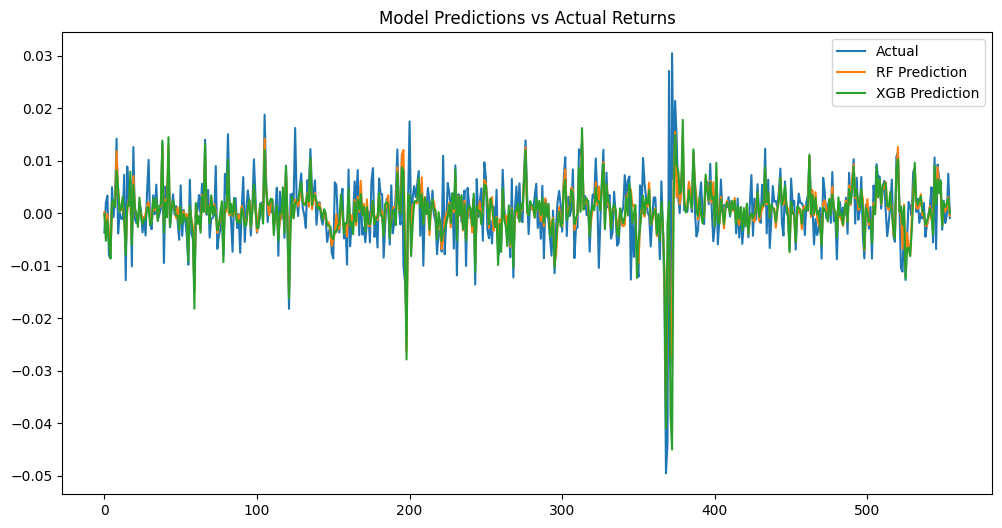

In [ ]:
# Plot predictions vs actual values

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(rf_pred, label='RF Prediction')
plt.plot(xgb_pred, label='XGB Prediction')

plt.title("Model Predictions vs Actual Returns")
plt.legend()
plt.show()

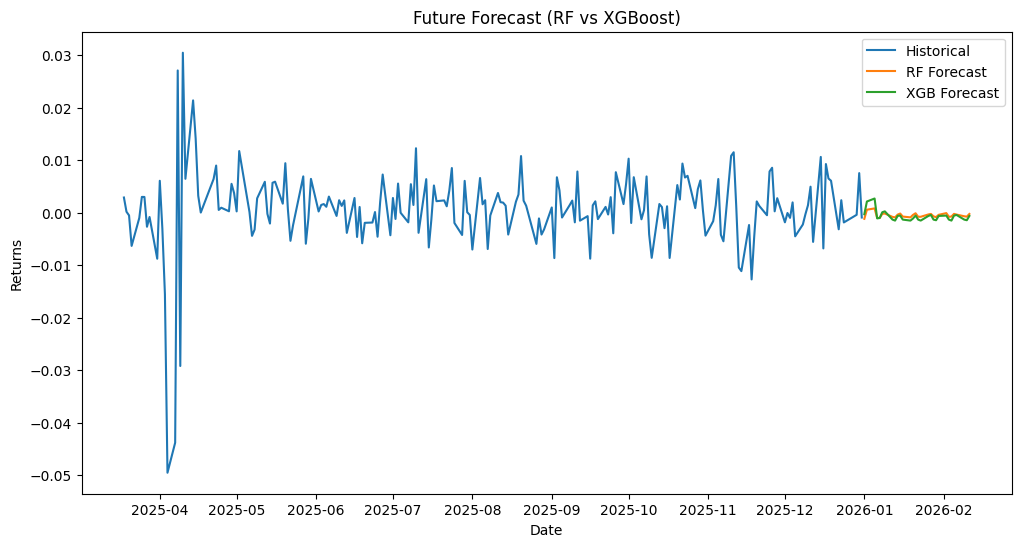

In [ ]:
# FUTURE FORECAST (RF + XGBOOST)

# Number of future steps
n_steps = 30

# Copy last known data
future_df = df.copy()

rf_future_preds = []
xgb_future_preds = []

for i in range(n_steps):

    # Get last row
    last_row = future_df.iloc[-1].copy()

    # Create new row (next day)
    new_row = last_row.copy()

    # --- Update lag features ---
    new_row['Lag1'] = last_row['Return']
    new_row['Lag2'] = last_row['Lag1']
    new_row['Lag3'] = last_row['Lag2']

    # --- Keep macro variables constant (assumption) ---
    new_row['Rate'] = last_row['Rate']
    new_row['Rate_Event'] = 0
    new_row['Rate_Direction'] = 0

    # --- Rolling stats update ---
    recent_returns = list(future_df['Return'].iloc[-4:]) + [last_row['Return']]
    new_row['Rolling_Mean_5'] = np.mean(recent_returns)
    new_row['Rolling_Std_5'] = np.std(recent_returns)

    # --- Momentum update ---
    new_row['Momentum'] = last_row['Price'] - future_df['Price'].iloc[-5]

    # --- High-Low Spread (assume constant) ---
    new_row['High_Low_Spread'] = last_row['High_Low_Spread']

    # --- Other features unchanged ---
    new_row['Open'] = last_row['Open']
    new_row['High'] = last_row['High']
    new_row['Low'] = last_row['Low']
    new_row['Volume'] = last_row['Volume']

    # --- Predict ---
    X_input = new_row[features].values.reshape(1, -1)

    rf_pred_step = rf_model.predict(X_input)[0]
    xgb_pred_step = xgb_model.predict(X_input)[0]

    rf_future_preds.append(rf_pred_step)
    xgb_future_preds.append(xgb_pred_step)

    # --- Update return ---
    new_row['Return'] = rf_pred_step  # you can also use xgb_pred_step separately

    # --- Append new row ---
    future_df = pd.concat([future_df, pd.DataFrame([new_row])], ignore_index=True)

# --- Create future dates ---
last_date = df['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=n_steps+1, freq='B')[1:]

# --- Plot Forecast ---
plt.figure(figsize=(12,6))

# Historical (last 200 points)
plt.plot(df['Date'].iloc[-200:], df['Return'].iloc[-200:], label='Historical')

# RF Forecast
plt.plot(future_dates, rf_future_preds, label='RF Forecast')

# XGB Forecast
plt.plot(future_dates, xgb_future_preds, label='XGB Forecast')

plt.title("Future Forecast (RF vs XGBoost)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.show()

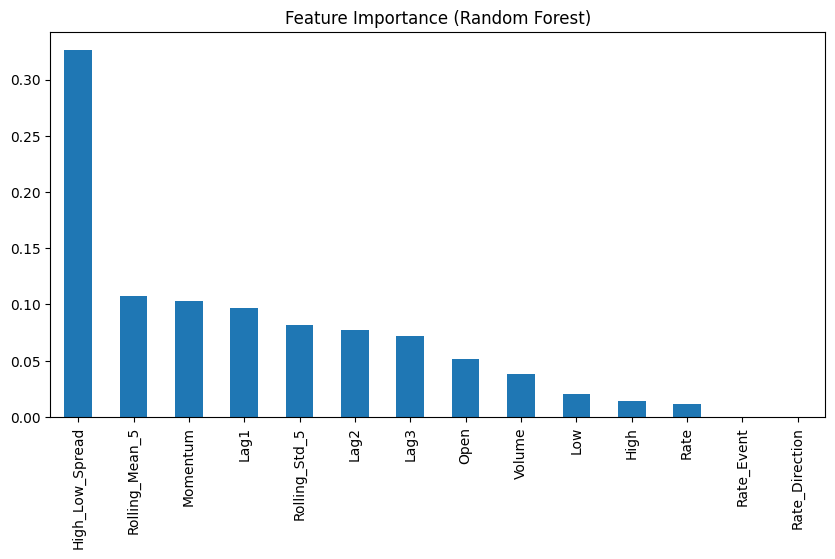

In [ ]:
# Feature importance from Random Forest

importance = pd.Series(rf_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

# Plot
importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

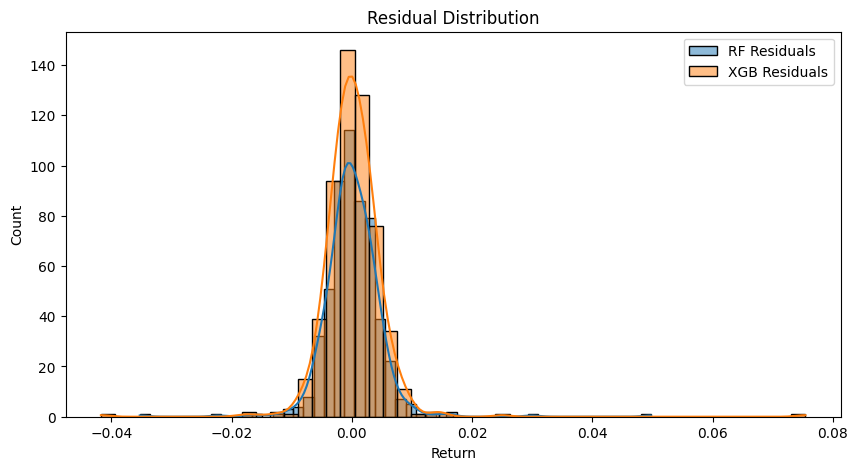

In [ ]:
# Residuals (errors)

rf_residuals = y_test - rf_pred
xgb_residuals = y_test - xgb_pred

# Plot residual distributions
plt.figure(figsize=(10,5))
sns.histplot(rf_residuals, bins=50, kde=True, label='RF Residuals')
sns.histplot(xgb_residuals, bins=50, kde=True, label='XGB Residuals')

plt.title("Residual Distribution")
plt.legend()
plt.show()

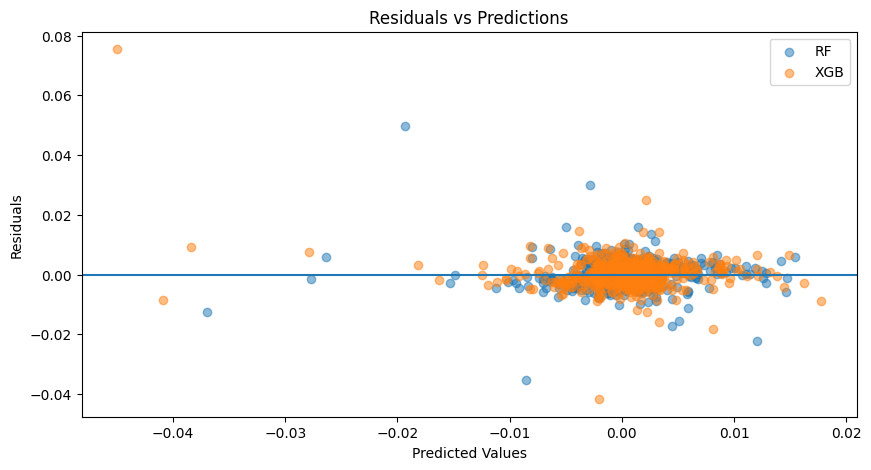

In [ ]:
# Check for bias patterns

plt.figure(figsize=(10,5))

plt.scatter(rf_pred, rf_residuals, alpha=0.5, label='RF')
plt.scatter(xgb_pred, xgb_residuals, alpha=0.5, label='XGB')

plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend()
plt.show()

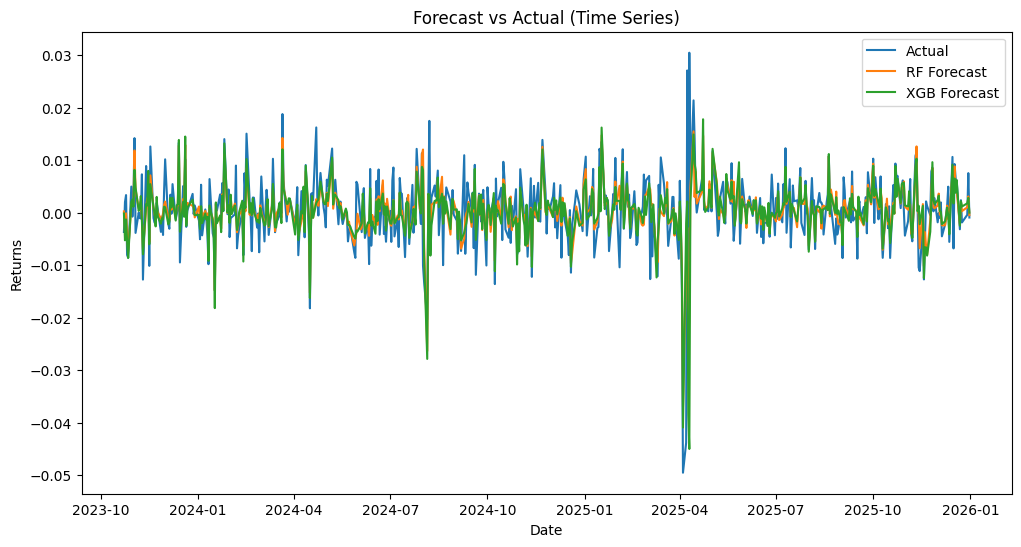

In [ ]:
# Plot predictions over time

plt.figure(figsize=(12,6))

plt.plot(df['Date'].iloc[-len(y_test):], y_test.values, label='Actual')
plt.plot(df['Date'].iloc[-len(y_test):], rf_pred, label='RF Forecast')
plt.plot(df['Date'].iloc[-len(y_test):], xgb_pred, label='XGB Forecast')

plt.title("Forecast vs Actual (Time Series)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.show()

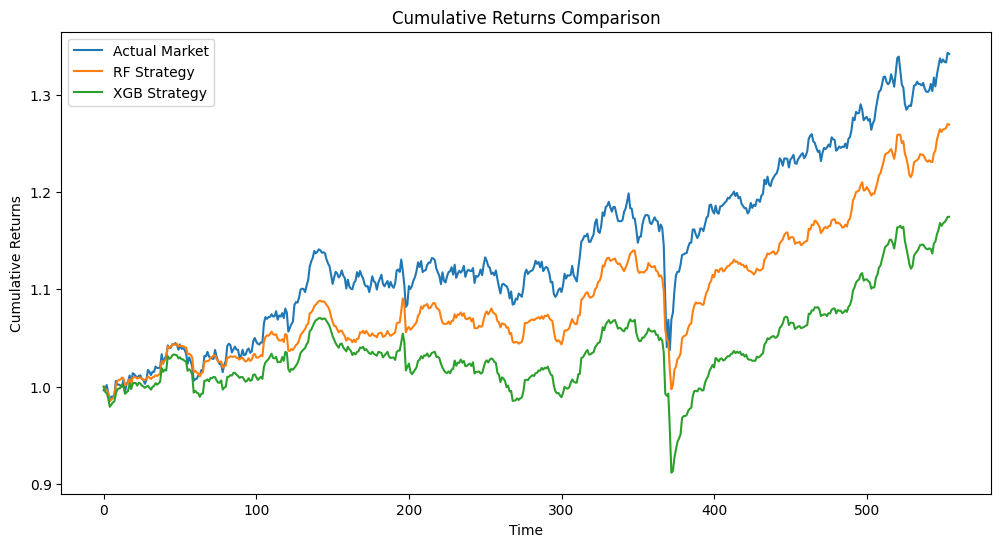

In [ ]:
# Convert everything to pandas Series for consistency

actual_cum = (1 + pd.Series(y_test).reset_index(drop=True)).cumprod()
rf_cum = (1 + pd.Series(rf_pred)).cumprod()
xgb_cum = (1 + pd.Series(xgb_pred)).cumprod()

# Plot cumulative returns

plt.figure(figsize=(12,6))

plt.plot(actual_cum, label='Actual Market')
plt.plot(rf_cum, label='RF Strategy')
plt.plot(xgb_cum, label='XGB Strategy')

plt.title("Cumulative Returns Comparison")
plt.xlabel("Time")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.show()

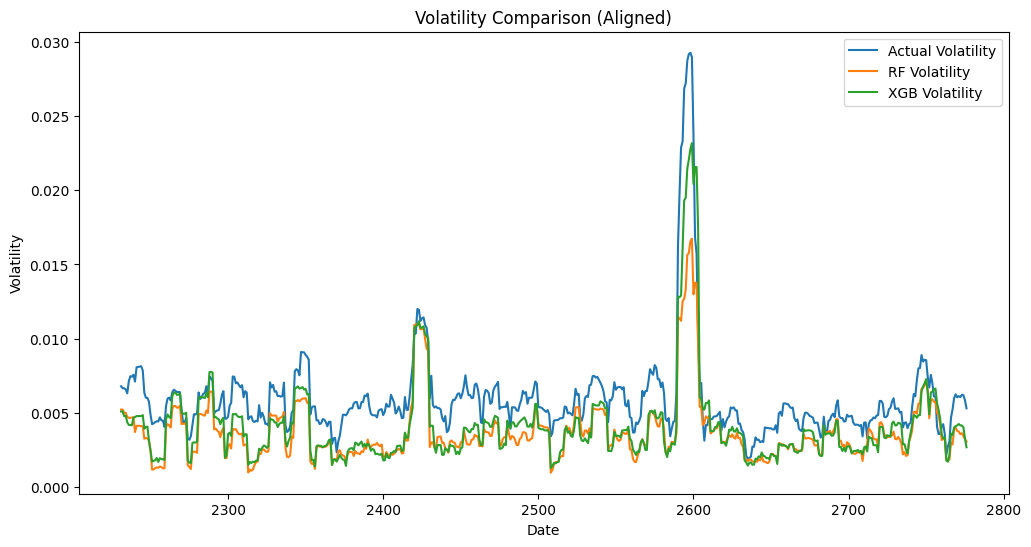

In [ ]:
# Align predictions with actual test index

rf_series = pd.Series(rf_pred, index=y_test.index)
xgb_series = pd.Series(xgb_pred, index=y_test.index)

# Compute rolling volatility
actual_vol = y_test.rolling(10).std()
rf_vol = rf_series.rolling(10).std()
xgb_vol = xgb_series.rolling(10).std()

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_vol, label='Actual Volatility')
plt.plot(rf_vol, label='RF Volatility')
plt.plot(xgb_vol, label='XGB Volatility')

plt.title("Volatility Comparison (Aligned)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [ ]:
# Create summary table

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    'MAE': [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    'R2': [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],
    'Directional Accuracy': [
        directional_accuracy(y_test, rf_pred),
        directional_accuracy(y_test, xgb_pred)
    ]
})

display(results)

,Model,RMSE,MAE,R2,Directional Accuracy
0,Random Forest,0.0049,0.0031,0.4668,0.7261
1,XGBoost,0.0054,0.0032,0.3485,0.7207


In [ ]:
# Install required packages

# !pip install statsmodels arch

In [ ]:
# Use returns for ARIMA and GARCH

# Ensure Date is index
ts = df.set_index('Date')['Return']

# Sort index
ts = ts.sort_index()

# Set frequency (Business Day)
ts = ts.asfreq('B')

# Fill missing values
ts = ts.fillna(method='ffill')

# Verify
print(ts.isna().sum())

0


In [ ]:
# Split data

train_size = int(len(ts) * 0.8)

train_ts = ts[:train_size]
test_ts = ts[train_size:]

print("Train size:", len(train_ts))
print("Test size:", len(test_ts))

Train size: 2289
Test size: 573


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Performance:
RMSE: 0.0066516423270956936
MAE : 0.004628337604512294


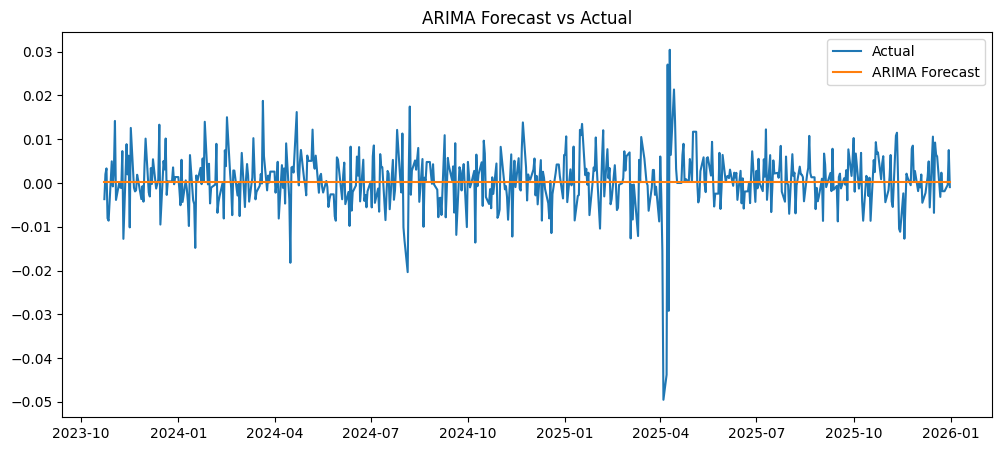

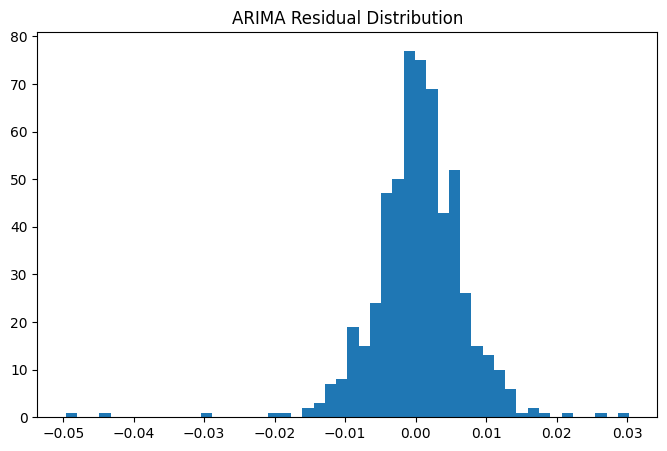

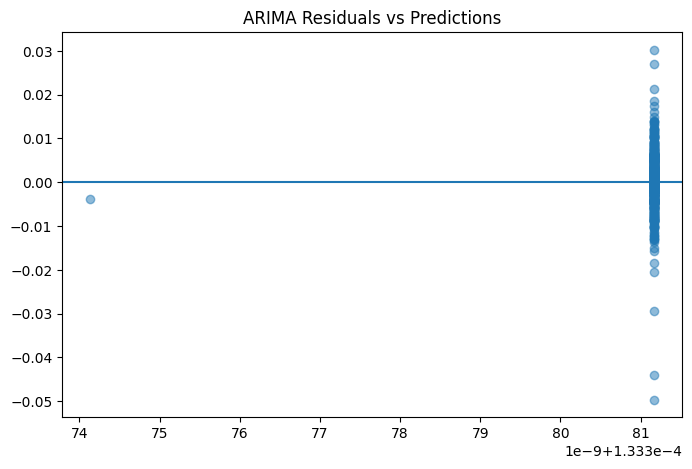

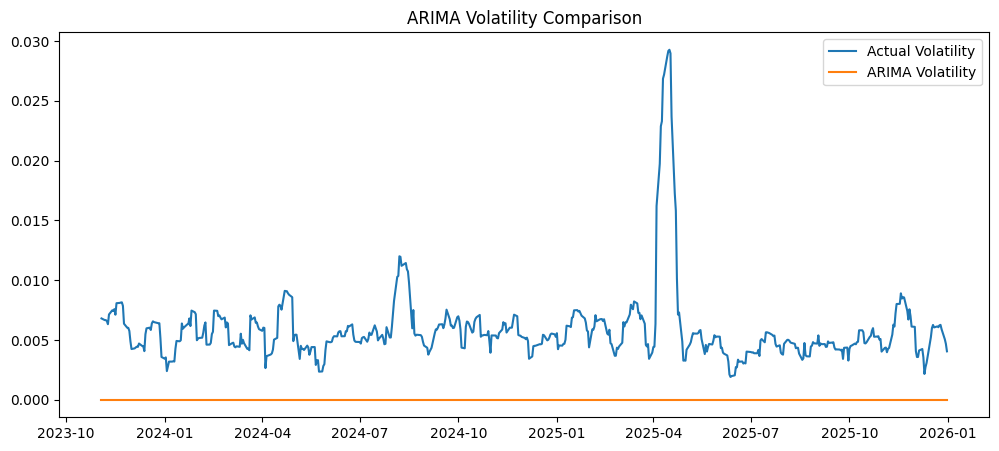

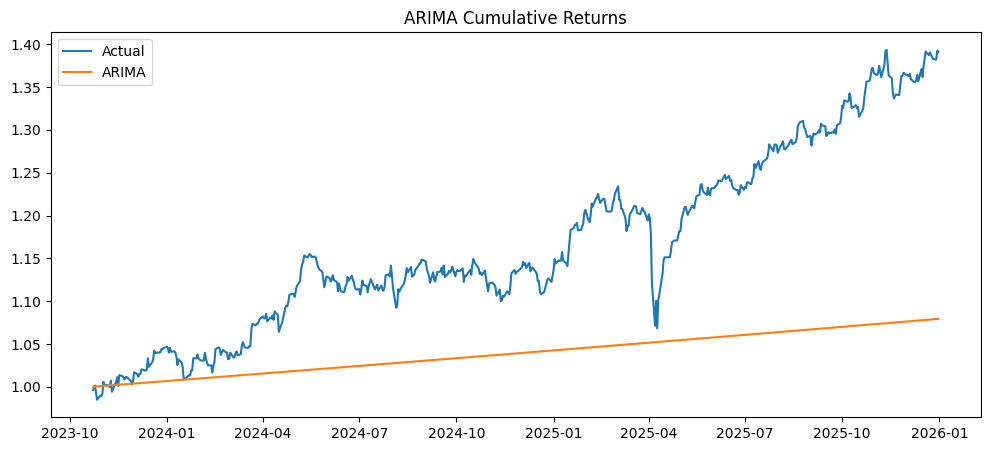

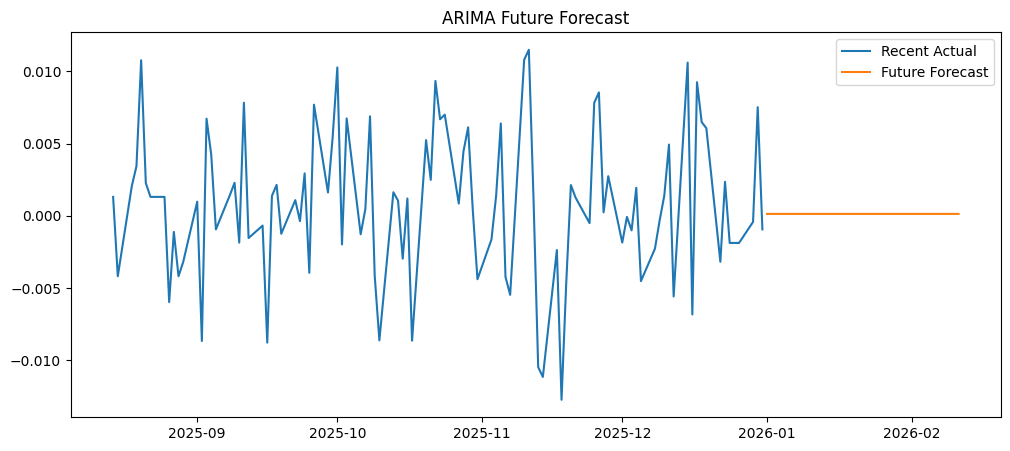

In [ ]:
# ARIMA MODEL: TRAIN + EVALUATE + FORECAST

from statsmodels.tsa.arima.model import ARIMA

# --- Train ARIMA ---
arima_model = ARIMA(train_ts, order=(1,0,1))
arima_fit = arima_model.fit()

# --- Predictions ---
arima_pred = arima_fit.forecast(steps=len(test_ts))
arima_pred = pd.Series(arima_pred, index=test_ts.index)

# --- Evaluation Metrics ---
rmse = np.sqrt(mean_squared_error(test_ts, arima_pred))
mae = mean_absolute_error(test_ts, arima_pred)

print("ARIMA Performance:")
print("RMSE:", rmse)
print("MAE :", mae)

# --- Residuals ---
residuals = test_ts - arima_pred

# --- Plot: Forecast vs Actual ---
plt.figure(figsize=(12,5))
plt.plot(test_ts, label='Actual')
plt.plot(arima_pred, label='ARIMA Forecast')
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

# --- Residual Distribution ---
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("ARIMA Residual Distribution")
plt.show()

# --- Residuals vs Predictions ---
plt.figure(figsize=(8,5))
plt.scatter(arima_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.title("ARIMA Residuals vs Predictions")
plt.show()

# --- Volatility Comparison ---
actual_vol = test_ts.rolling(10).std()
arima_vol = arima_pred.rolling(10).std()

plt.figure(figsize=(12,5))
plt.plot(actual_vol, label='Actual Volatility')
plt.plot(arima_vol, label='ARIMA Volatility')
plt.title("ARIMA Volatility Comparison")
plt.legend()
plt.show()

# --- Cumulative Returns ---
actual_cum = (1 + test_ts).cumprod()
arima_cum = (1 + arima_pred).cumprod()

plt.figure(figsize=(12,5))
plt.plot(actual_cum, label='Actual')
plt.plot(arima_cum, label='ARIMA')
plt.title("ARIMA Cumulative Returns")
plt.legend()
plt.show()

# --- Future Forecast (30 steps) ---
future_steps = 30
future_forecast = arima_fit.forecast(steps=future_steps)

# Create future dates
future_dates = pd.date_range(start=test_ts.index[-1], periods=future_steps+1, freq='B')[1:]

plt.figure(figsize=(12,5))
plt.plot(test_ts[-100:], label='Recent Actual')
plt.plot(future_dates, future_forecast, label='Future Forecast')
plt.title("ARIMA Future Forecast")
plt.legend()
plt.show()

GARCH Volatility Performance:
RMSE: 0.004983268275959993
MAE : 0.004498713714038531


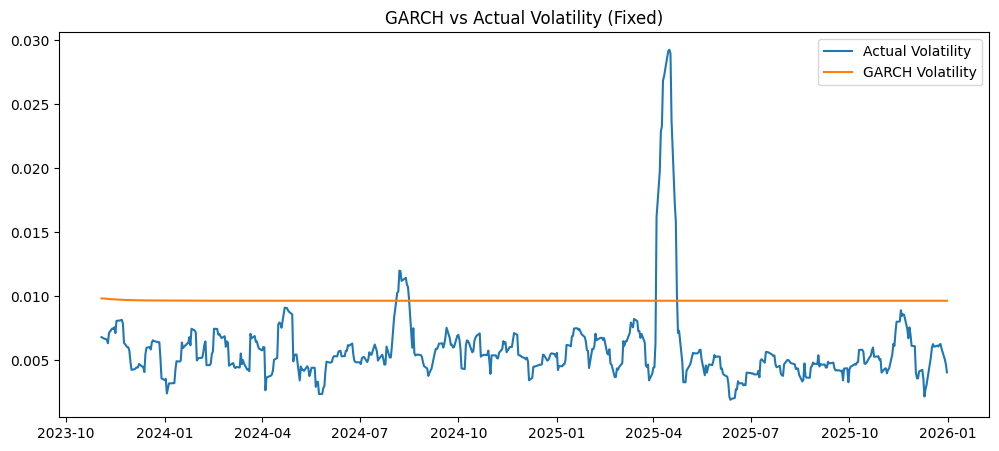

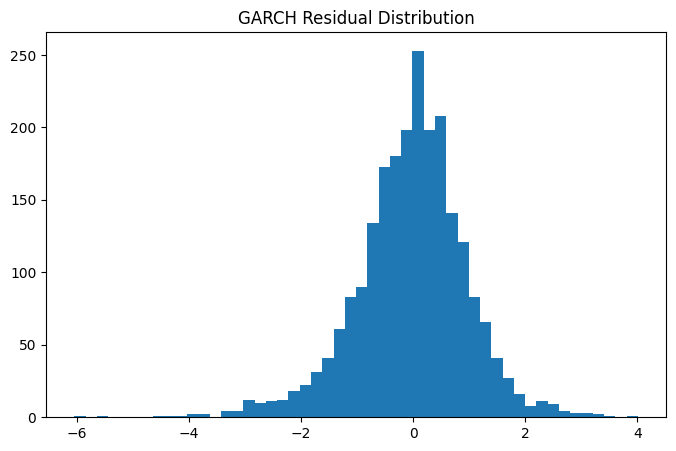

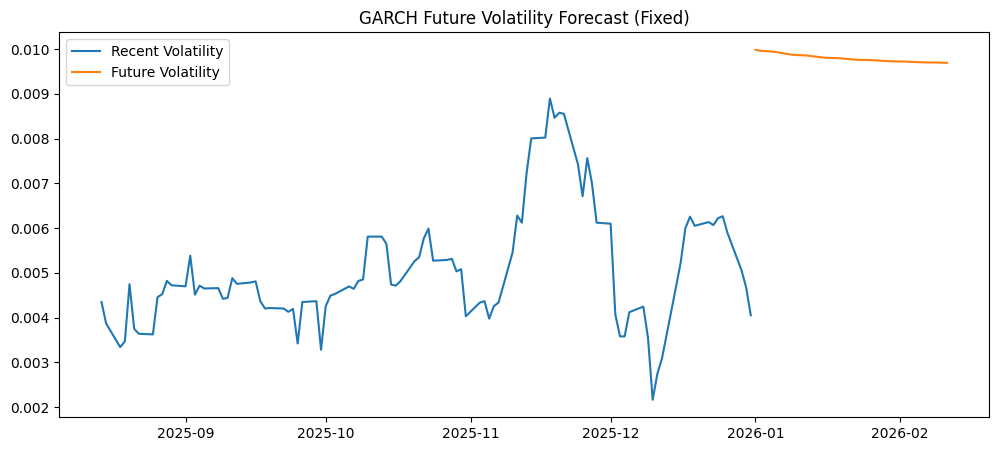

In [ ]:
# GARCH MODEL: TRAIN + EVALUATE + FORECAST

from arch import arch_model

# Train GARCH (scaled data)
garch = arch_model(train_ts * 100, vol='Garch', p=1, q=1)
garch_fit = garch.fit(disp='off')

# Forecast
garch_forecast = garch_fit.forecast(horizon=len(test_ts))

# Extract variance → volatility
garch_var = garch_forecast.variance.values[-1]
garch_vol = np.sqrt(garch_var)

# Scale back to original
garch_vol = garch_vol / 100

# Convert to series
garch_vol = pd.Series(garch_vol, index=test_ts.index)

# Actual Volatility
actual_vol = test_ts.rolling(10).std()

# Align
vol_df = pd.concat([actual_vol, garch_vol], axis=1)
vol_df.columns = ['Actual_Vol', 'GARCH_Vol']
vol_df = vol_df.dropna()

# Evaluation
rmse = np.sqrt(mean_squared_error(vol_df['Actual_Vol'], vol_df['GARCH_Vol']))
mae = mean_absolute_error(vol_df['Actual_Vol'], vol_df['GARCH_Vol'])

print("GARCH Volatility Performance:")
print("RMSE:", rmse)
print("MAE :", mae)

# Plot
plt.figure(figsize=(12,5))
plt.plot(vol_df.index, vol_df['Actual_Vol'], label='Actual Volatility')
plt.plot(vol_df.index, vol_df['GARCH_Vol'], label='GARCH Volatility')
plt.title("GARCH vs Actual Volatility (Fixed)")
plt.legend()
plt.show()

# Residuals
residuals = garch_fit.resid / garch_fit.conditional_volatility

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("GARCH Residual Distribution")
plt.show()

# Future Forecast
future_steps = 30

future_forecast = garch_fit.forecast(horizon=future_steps)
future_var = future_forecast.variance.values[-1]
future_vol = np.sqrt(future_var)

# Scale back
future_vol = future_vol / 100

# Future dates
future_dates = pd.date_range(start=test_ts.index[-1], periods=future_steps+1, freq='B')[1:]

# Plot
plt.figure(figsize=(12,5))
plt.plot(actual_vol.tail(100), label='Recent Volatility')
plt.plot(future_dates, future_vol, label='Future Volatility')
plt.title("GARCH Future Volatility Forecast (Fixed)")
plt.legend()
plt.show()

In [ ]:
# LSTM requires scaled data

from sklearn.preprocessing import MinMaxScaler

# Select features again
features = [
    'Open', 'High', 'Low', 'Volume',
    'Rate', 'Rate_Event', 'Rate_Direction',
    'Lag1', 'Lag2', 'Lag3',
    'Rolling_Mean_5', 'Rolling_Std_5',
    'High_Low_Spread', 'Momentum'
]

target = 'Return'

X = df[features]
y = df[target]

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Convert data into sequences for LSTM

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y.iloc[i+time_steps])

    return np.array(Xs), np.array(ys)

# Create sequences
time_steps = 10
X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

print("Shape of X_seq:", X_seq.shape)
print("Shape of y_seq:", y_seq.shape)

Shape of X_seq: (2762, 10, 14)
Shape of y_seq: (2762,)


In [ ]:
# Split without shuffling

train_size = int(len(X_seq) * 0.8)

X_train_seq = X_seq[:train_size]
X_test_seq = X_seq[train_size:]

y_train_seq = y_seq[:train_size]
y_test_seq = y_seq[train_size:]

print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)

Train shape: (2209, 10, 14)
Test shape: (553, 10, 14)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.3838e-04 - val_loss: 6.1734e-05
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.4287e-04 - val_loss: 5.8495e-05
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3934e-04 - val_loss: 6.2013e-05
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3927e-04 - val_loss: 6.4580e-05
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3593e-04 - val_loss: 5.5985e-05
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2892e-04 - val_loss: 6.1453e-05
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2899e-04 - val_loss: 5.5952e-05
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3379e-04 - val_loss: 7.2136e-05
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3869e-04 - val_loss: 6.5011e-05
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3088e-04 - val_loss: 5.6311e-05
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2629e-04 - val_l

In [ ]:
# Predict on test data

lstm_pred = model.predict(X_test_seq).flatten()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("LSTM Performance:")
evaluate_all(y_test_seq, lstm_pred, "LSTM")

LSTM Performance:

LSTM Performance:
RMSE : 0.007214852866980879
MAE  : 0.005233317691538843
R²   : -0.15401985673518004
MAPE : 348.41694314859063
----------------------------------------


In [ ]:
# Directional accuracy

direction_acc = np.mean((np.sign(y_test_seq) == np.sign(lstm_pred)).astype(int))

print("LSTM Directional Accuracy:", direction_acc)

LSTM Directional Accuracy: 0.46835443037974683


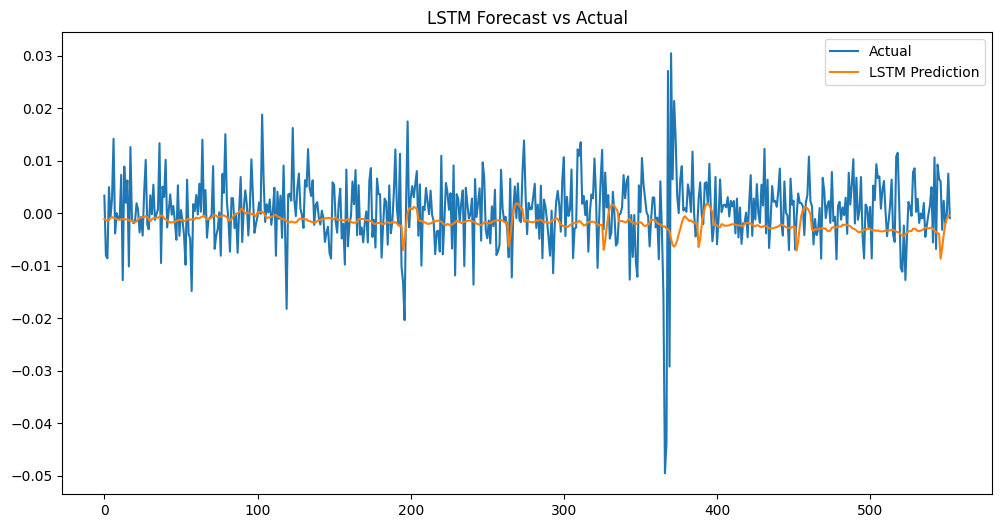

In [ ]:
# Align index for plotting

y_test_series = pd.Series(y_test_seq)
lstm_series = pd.Series(lstm_pred, index=y_test_series.index)

# Plot predictions

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_series.values, label='Actual')
plt.plot(lstm_series.values, label='LSTM Prediction')

plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()

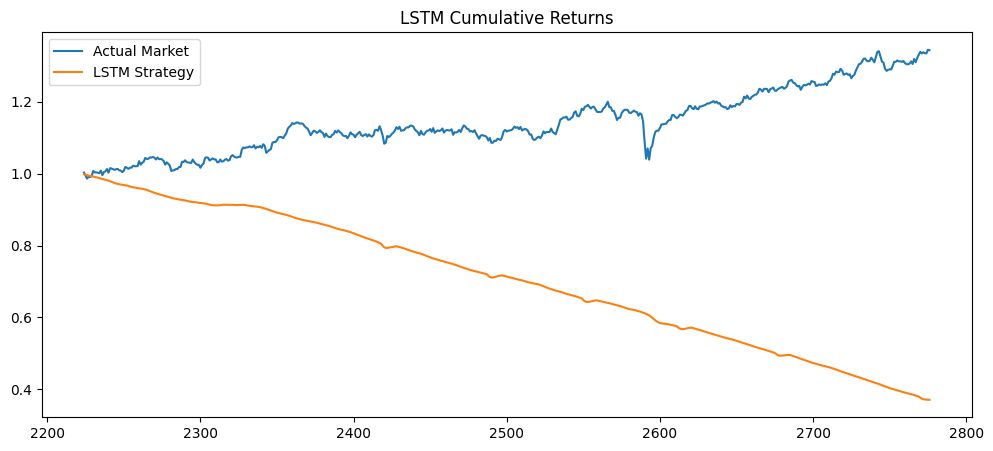

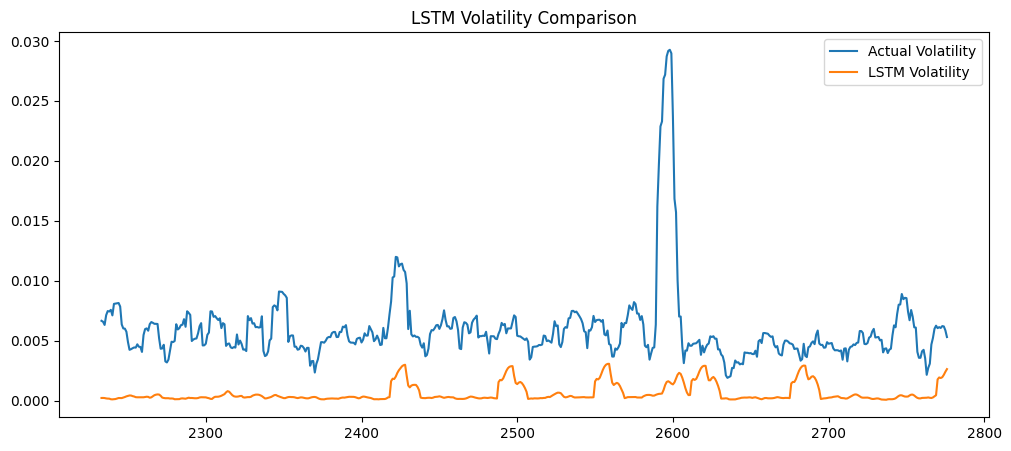

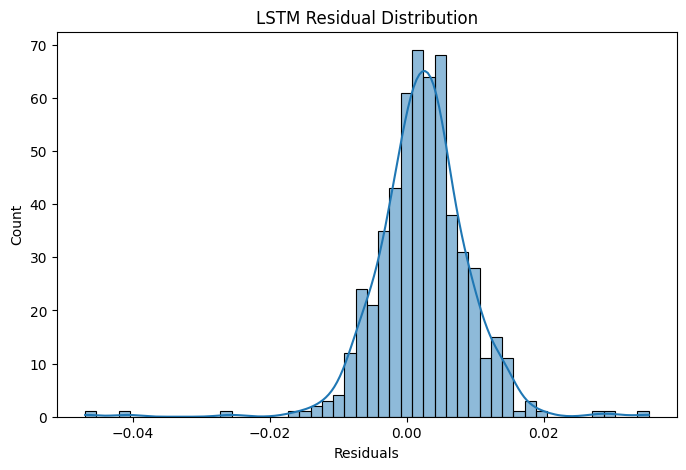

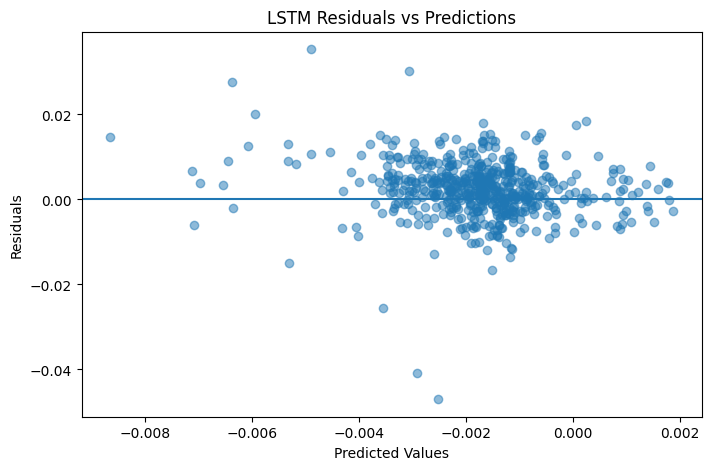

In [ ]:
# ==============================
# LSTM FULL EVALUATION PLOTS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Align LSTM predictions with correct index
# Due to time_steps offset
lstm_index = df.index[-len(y_test_seq):]
y_true = pd.Series(y_test_seq, index=lstm_index)
y_pred = pd.Series(lstm_pred, index=lstm_index)

# Residuals
residuals = y_true - y_pred

# CUMULATIVE RETURNS
actual_cum = (1 + y_true).cumprod()
lstm_cum = (1 + y_pred).cumprod()

plt.figure(figsize=(12,5))
plt.plot(actual_cum, label='Actual Market')
plt.plot(lstm_cum, label='LSTM Strategy')
plt.title("LSTM Cumulative Returns")
plt.legend()
plt.show()


# VOLATILITY COMPARISON
actual_vol = y_true.rolling(10).std()
lstm_vol = y_pred.rolling(10).std()

plt.figure(figsize=(12,5))
plt.plot(actual_vol, label='Actual Volatility')
plt.plot(lstm_vol, label='LSTM Volatility')
plt.title("LSTM Volatility Comparison")
plt.legend()
plt.show()


# RESIDUAL DISTRIBUTION
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("LSTM Residual Distribution")
plt.xlabel("Residuals")
plt.show()


# RESIDUALS vs PREDICTIONS
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.title("LSTM Residuals vs Predictions")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# Function to forecast future values using LSTM

def forecast_future(model, last_sequence, n_steps, scaler):
    """
    model: trained LSTM model
    last_sequence: last known sequence (shape: time_steps x features)
    n_steps: number of future steps to predict
    scaler: fitted scaler
    """

    future_predictions = []
    current_seq = last_sequence.copy()

    for _ in range(n_steps):

        # Predict next step
        pred = model.predict(current_seq.reshape(1, current_seq.shape[0], current_seq.shape[1]))
        pred_value = pred[0][0]

        future_predictions.append(pred_value)

        # Create next input sequence
        next_step = current_seq[-1].copy()

        # Replace target-related feature (approximation)
        next_step[0] = pred_value  # approximate (depends on feature structure)

        # Shift window
        current_seq = np.vstack([current_seq[1:], next_step])

    return np.array(future_predictions)

In [ ]:
# Get last sequence from test data

last_sequence = X_seq[-1]

# Forecast next 30 days
future_steps = 30

future_preds = forecast_future(model, last_sequence, future_steps, scaler)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

In [ ]:
# Generate future dates

last_date = df['Date'].iloc[-1]

future_dates = pd.date_range(start=last_date, periods=future_steps+1, freq='B')[1:]

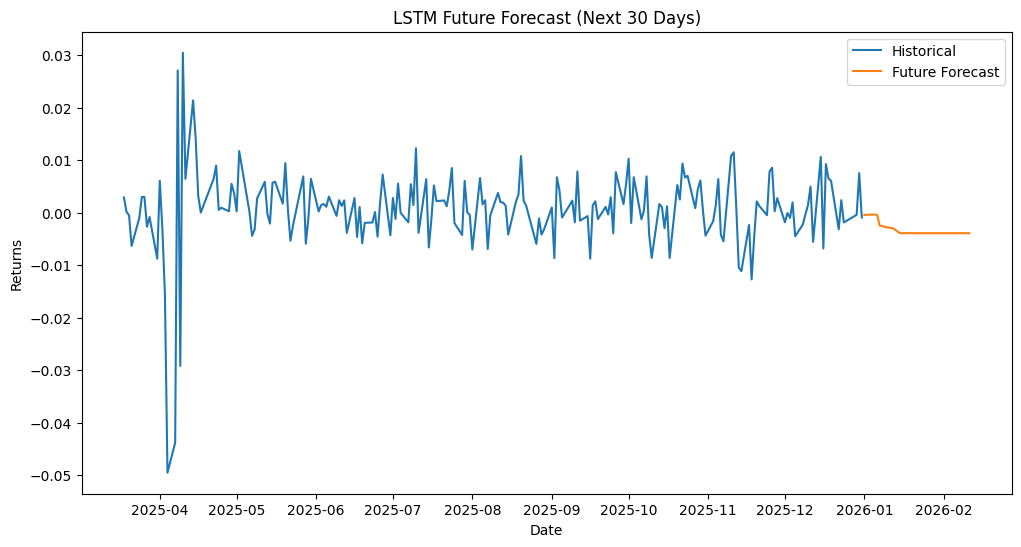

In [ ]:
# Plot future forecast

plt.figure(figsize=(12,6))

# Historical data (last 200 points)
plt.plot(df['Date'].iloc[-200:], df['Return'].iloc[-200:], label='Historical')

# Future predictions
plt.plot(future_dates, future_preds, label='Future Forecast')

plt.title("LSTM Future Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.show()